In [7]:
import pandas as pd
import numpy as np
import re
import string
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, ngrams as nltk_ngrams
from nltk.probability import FreqDist

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

In [10]:
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser

In [11]:
df = pd.read_csv('pak-Liar.csv', encoding='latin-1')
print('Shape:', df.shape)
df.head()

Shape: (4813, 9)


,[ID],label,statement,subject(s),speaker,speaker's job title,state info,party affiliation,venue
0,1913,True,This is a test of the Share the Facts widget.,technology,18-percent-american-public,NaN,NaN,none,a test conducted on an obscure PolitiFact site.
1,4779,True,"""Pakistan launches a nationwide anti-polio dri...",Healthcare,Abdul Qadir Patel,Health Minister,Federal,PPP,Press Release
2,4731,True,"""Pakistan launches a nationwide anti-polio dri...",Healthcare,Abdul Qadir Patel,Health Minister,Federal,PPP,Press Release
3,4596,True,"""Pakistani student Zara Naeem tops ACCA global...",Education,ACCA,Exam Body,Punjab,NaN,Result
4,4657,True,"""Special Court acquits former Prime Minister i...",Law,Accountability Court,Judiciary,Federal,NaN,Verdict


In [12]:
df.drop(columns=['[ID]'], inplace=True)
df.columns = ['label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'venue']
df['label'] = df['label'].astype(int)
print('Label distribution:')
print(df['label'].value_counts())
print()
print('Null counts:')
print(df.isnull().sum())

Label distribution:
label
0    2627
1    2186
Name: count, dtype: int64

Null counts:
label           0
statement       0
subject         0
speaker         0
job_title    1271
state         928
party         189
venue          52
dtype: int64


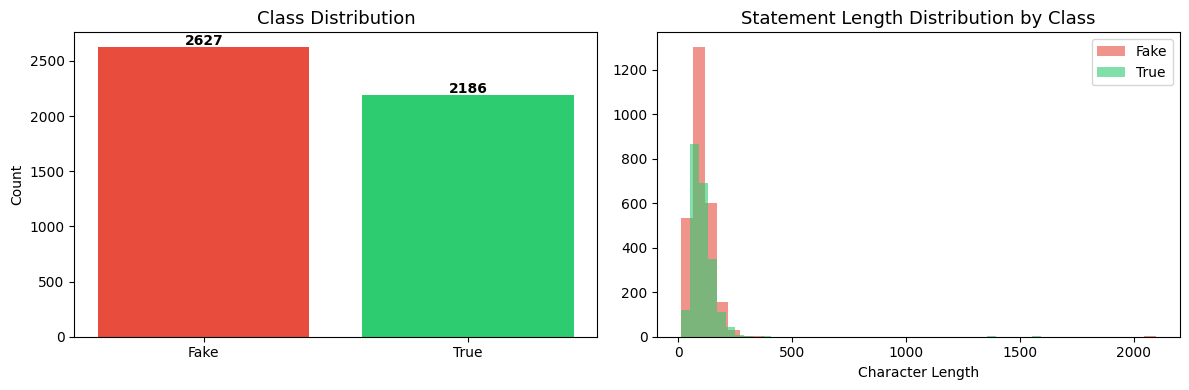

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_names = {0: 'Fake', 1: 'True'}
counts = df['label'].value_counts().rename(index=label_names)
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

df['stmt_len'] = df['statement'].str.len()
for lbl, col, name in [(0, '#e74c3c', 'Fake'), (1, '#2ecc71', 'True')]:
    axes[1].hist(df[df['label'] == lbl]['stmt_len'], bins=40, alpha=0.6, color=col, label=name)
axes[1].set_title('Statement Length Distribution by Class', fontsize=13)
axes[1].set_xlabel('Character Length')
axes[1].legend()

plt.tight_layout()
plt.show()

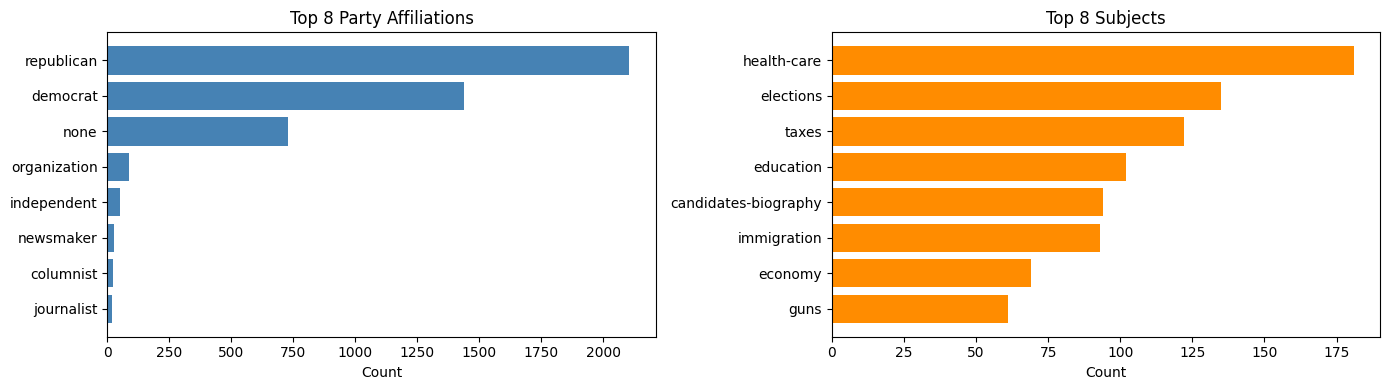

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_parties = df['party'].value_counts().nlargest(8)
axes[0].barh(top_parties.index[::-1], top_parties.values[::-1], color='steelblue')
axes[0].set_title('Top 8 Party Affiliations')
axes[0].set_xlabel('Count')

top_subjects = df['subject'].value_counts().nlargest(8)
axes[1].barh(top_subjects.index[::-1], top_subjects.values[::-1], color='darkorange')
axes[1].set_title('Top 8 Subjects')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [15]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOP_WORDS and len(w) > 1)

def lemmatize_text(text):
    tokens = word_tokenize(text)
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

def stem_text(text):
    return ' '.join(stemmer.stem(w) for w in text.split())

def full_preprocess(text, use_stemming=False):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    if use_stemming:
        text = stem_text(text)
    return text

In [16]:
print('Preprocessing statements...')
df['statement_clean'] = df['statement'].apply(lambda x: full_preprocess(x, use_stemming=False))
df['statement_stemmed'] = df['statement'].apply(lambda x: full_preprocess(x, use_stemming=True))

for col in ['subject', 'speaker', 'job_title', 'party', 'venue', 'state']:
    df[col] = df[col].fillna('unknown').str.lower().str.strip()
    df[col] = df[col].apply(lambda x: re.sub(r'[^a-z0-9\s]', ' ', x))
    df[col] = df[col].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print('Done. Sample cleaned statement:')
print('Original:', df['statement'].iloc[1][:100])
print('Cleaned: ', df['statement_clean'].iloc[1][:100])

Preprocessing statements...
Done. Sample cleaned statement:
Original: "Pakistan launches a nationwide anti-polio drive targeting over 40 million children."
Cleaned:  pakistan launch nationwide anti polio drive targeting num million child


In [17]:
def get_pos_features(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    pos_counts = Counter(tag for _, tag in tags)
    total = max(len(tags), 1)
    nouns = (pos_counts.get('NN', 0) + pos_counts.get('NNS', 0) +
             pos_counts.get('NNP', 0) + pos_counts.get('NNPS', 0))
    verbs = (pos_counts.get('VB', 0) + pos_counts.get('VBD', 0) +
             pos_counts.get('VBG', 0) + pos_counts.get('VBN', 0) +
             pos_counts.get('VBP', 0) + pos_counts.get('VBZ', 0))
    adjectives = pos_counts.get('JJ', 0) + pos_counts.get('JJR', 0) + pos_counts.get('JJS', 0)
    adverbs = pos_counts.get('RB', 0) + pos_counts.get('RBR', 0) + pos_counts.get('RBS', 0)
    return [
        nouns / total,
        verbs / total,
        adjectives / total,
        adverbs / total,
        len(tokens)
    ]

print('Extracting POS features (this may take a moment)...')
pos_features = np.array([get_pos_features(t) for t in df['statement_clean']])
pos_feature_names = ['noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'token_count']
df_pos = pd.DataFrame(pos_features, columns=pos_feature_names)
print('POS features extracted. Shape:', df_pos.shape)
df_pos.describe()

Extracting POS features (this may take a moment)...
POS features extracted. Shape: (4813, 5)


,noun_ratio,verb_ratio,adj_ratio,adv_ratio,token_count
count,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000
mean,0.563583,0.162213,0.177152,0.042016,10.720549
std,0.149029,0.106456,0.118146,0.067574,6.900419
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.461538,0.100000,0.100000,0.000000,8.000000
50%,0.555556,0.153846,0.166667,0.000000,10.000000
75%,0.666667,0.227273,0.250000,0.083333,13.000000
max,1.000000,1.000000,1.000000,0.500000,278.000000


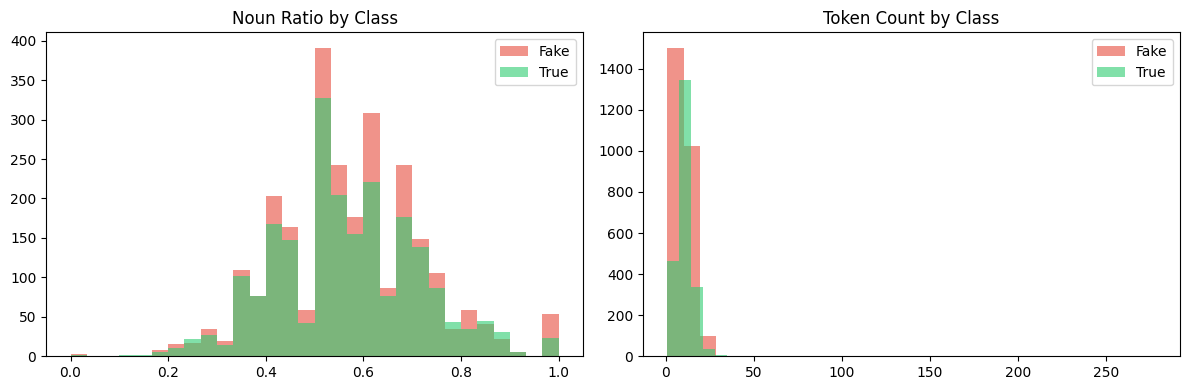

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lbl, col, name in [(0, '#e74c3c', 'Fake'), (1, '#2ecc71', 'True')]:
    mask = df['label'] == lbl
    axes[0].hist(df_pos.loc[mask, 'noun_ratio'], bins=30, alpha=0.6, color=col, label=name)
    axes[1].hist(df_pos.loc[mask, 'token_count'], bins=30, alpha=0.6, color=col, label=name)
axes[0].set_title('Noun Ratio by Class')
axes[0].legend()
axes[1].set_title('Token Count by Class')
axes[1].legend()
plt.tight_layout()
plt.show()

In [19]:
def extract_hand_features(row):
    stmt = str(row['statement'])
    features = [
        len(stmt),
        len(stmt.split()),
        stmt.count('?'),
        stmt.count('!'),
        stmt.count('"'),
        sum(1 for c in stmt if c.isupper()) / max(len(stmt), 1),
        len(re.findall(r'\d+', stmt)),
        len(re.findall(r'%', stmt)),
        1 if re.search(r'\b(million|billion|trillion|percent|%)\b', stmt.lower()) else 0,
        1 if re.search(r'\b(says|said|claims|argues|states)\b', stmt.lower()) else 0,
        1 if re.search(r'\b(never|always|all|none|every|no one|everyone)\b', stmt.lower()) else 0,
    ]
    return features

hand_features = np.array([extract_hand_features(row) for _, row in df.iterrows()])
hand_feat_names = [
    'char_len', 'word_count', 'q_marks', 'excl_marks', 'quotes',
    'caps_ratio', 'num_count', 'percent_count', 'has_quantity',
    'has_speech_verb', 'has_absolute'
]
df_hand = pd.DataFrame(hand_features, columns=hand_feat_names)
print('Handcrafted features shape:', df_hand.shape)

Handcrafted features shape: (4813, 11)


In [20]:
meta_cols = ['subject', 'speaker', 'job_title', 'party', 'venue', 'state']

le_dict = {}
meta_encoded = np.zeros((len(df), len(meta_cols)))
for i, col in enumerate(meta_cols):
    le = LabelEncoder()
    meta_encoded[:, i] = le.fit_transform(df[col])
    le_dict[col] = le

df_meta = pd.DataFrame(meta_encoded, columns=[c + '_enc' for c in meta_cols])
print('Metadata features shape:', df_meta.shape)

Metadata features shape: (4813, 6)


In [21]:
party_label_rate = df.groupby('party')['label'].mean().reset_index()
party_label_rate.columns = ['party', 'party_truth_rate']
df = df.merge(party_label_rate, on='party', how='left')

speaker_label_rate = df.groupby('speaker')['label'].mean().reset_index()
speaker_label_rate.columns = ['speaker', 'speaker_truth_rate']
df = df.merge(speaker_label_rate, on='speaker', how='left')

df_target_enc = df[['party_truth_rate', 'speaker_truth_rate']].fillna(0.5)
print('Target-encoded features shape:', df_target_enc.shape)

Target-encoded features shape: (4813, 2)


In [22]:
X_text = df['statement_clean']
X_stemmed = df['statement_stemmed']
y = df['label'].values

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

y_train = y[train_idx]
y_test = y[test_idx]

print('Train size:', len(train_idx))
print('Test size:', len(test_idx))
print('Train class balance:', np.bincount(y_train))
print('Test class balance:', np.bincount(y_test))

Train size: 3850
Test size: 963
Train class balance: [2101 1749]
Test class balance: [526 437]


In [23]:
bow_unigram = CountVectorizer(max_features=15000, ngram_range=(1, 1), min_df=2)
X_bow_train = bow_unigram.fit_transform(X_text.iloc[train_idx])
X_bow_test  = bow_unigram.transform(X_text.iloc[test_idx])
print('BoW (unigram) train shape:', X_bow_train.shape)

BoW (unigram) train shape: (3850, 3355)


In [24]:
tfidf_unigram = TfidfVectorizer(max_features=15000, ngram_range=(1, 1),
                                 sublinear_tf=True, min_df=2)
X_tfidf1_train = tfidf_unigram.fit_transform(X_text.iloc[train_idx])
X_tfidf1_test  = tfidf_unigram.transform(X_text.iloc[test_idx])

tfidf_bigram = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                sublinear_tf=True, min_df=2)
X_tfidf2_train = tfidf_bigram.fit_transform(X_text.iloc[train_idx])
X_tfidf2_test  = tfidf_bigram.transform(X_text.iloc[test_idx])

tfidf_trigram = TfidfVectorizer(max_features=25000, ngram_range=(1, 3),
                                 sublinear_tf=True, min_df=2)
X_tfidf3_train = tfidf_trigram.fit_transform(X_text.iloc[train_idx])
X_tfidf3_test  = tfidf_trigram.transform(X_text.iloc[test_idx])

tfidf_char = TfidfVectorizer(max_features=20000, analyzer='char_wb',
                              ngram_range=(3, 5), sublinear_tf=True, min_df=3)
X_tfidf_char_train = tfidf_char.fit_transform(X_text.iloc[train_idx])
X_tfidf_char_test  = tfidf_char.transform(X_text.iloc[test_idx])

print('TF-IDF unigram  train shape:', X_tfidf1_train.shape)
print('TF-IDF bigram   train shape:', X_tfidf2_train.shape)
print('TF-IDF trigram  train shape:', X_tfidf3_train.shape)
print('TF-IDF char     train shape:', X_tfidf_char_train.shape)

TF-IDF unigram  train shape: (3850, 3355)
TF-IDF bigram   train shape: (3850, 6727)
TF-IDF trigram  train shape: (3850, 8234)
TF-IDF char     train shape: (3850, 18187)


In [25]:
tfidf_meta_parts_train = []
tfidf_meta_parts_test  = []
meta_tfidf_vecs = {}

for col in ['subject', 'speaker', 'job_title', 'party']:
    vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), sublinear_tf=True)
    tr = vec.fit_transform(df[col].iloc[train_idx])
    te = vec.transform(df[col].iloc[test_idx])
    tfidf_meta_parts_train.append(tr)
    tfidf_meta_parts_test.append(te)
    meta_tfidf_vecs[col] = vec

X_meta_tfidf_train = hstack(tfidf_meta_parts_train)
X_meta_tfidf_test  = hstack(tfidf_meta_parts_test)
print('Meta TF-IDF train shape:', X_meta_tfidf_train.shape)

Meta TF-IDF train shape: (3850, 6786)


In [26]:
tokenized_corpus = [text.split() for text in df['statement_clean']]
bigram_phraser = Phrases(tokenized_corpus, min_count=5, threshold=10)
bigram_phraser = Phraser(bigram_phraser)
phrased_corpus = [bigram_phraser[tokens] for tokens in tokenized_corpus]

w2v_model = Word2Vec(
    sentences=phrased_corpus,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    sg=1,
    negative=10,
    seed=42
)

print('Word2Vec vocabulary size:', len(w2v_model.wv))
print('Vector size:', w2v_model.vector_size)
print('Sample similar words to "pakistan":')
try:
    print(w2v_model.wv.most_similar('pakistan', topn=5))
except KeyError:
    print('(word not in vocabulary, try another)')

Word2Vec vocabulary size: 4092
Vector size: 200
Sample similar words to "pakistan":
[('covid', 0.785781741142273), ('gold', 0.7854763865470886), ('tranche', 0.7815621495246887), ('assist', 0.7697134613990784), ('successfully', 0.7633781433105469)]


In [27]:
def get_w2v_vector(text, model, phraser):
    tokens = phraser[text.split()]
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

def get_w2v_vector_weighted(text, model, phraser, tfidf_vec, tfidf_matrix_row):
    tokens = phraser[text.split()]
    vocab = tfidf_vec.vocabulary_
    idf = tfidf_vec.idf_
    weighted_vecs = []
    for w in tokens:
        if w in model.wv:
            weight = idf[vocab[w]] if w in vocab else 1.0
            weighted_vecs.append(model.wv[w] * weight)
    if not weighted_vecs:
        return np.zeros(model.vector_size)
    return np.mean(weighted_vecs, axis=0)

print('Building Word2Vec feature matrix (mean pooling)...')
X_w2v_all = np.array([get_w2v_vector(t, w2v_model, bigram_phraser)
                      for t in df['statement_clean']])
X_w2v_train = X_w2v_all[train_idx]
X_w2v_test  = X_w2v_all[test_idx]
print('Word2Vec feature matrix shape:', X_w2v_train.shape)

Building Word2Vec feature matrix (mean pooling)...
Word2Vec feature matrix shape: (3850, 200)


In [28]:
dense_feats_all = np.hstack([
    pos_features,
    hand_features,
    meta_encoded,
    df_target_enc.values
])
scaler = MaxAbsScaler()
dense_train = scaler.fit_transform(dense_feats_all[train_idx])
dense_test  = scaler.transform(dense_feats_all[test_idx])
print('Dense feature matrix shape:', dense_train.shape)

Dense feature matrix shape: (3850, 24)


In [29]:
X_full_train = hstack([
    X_tfidf3_train,
    X_tfidf_char_train,
    X_meta_tfidf_train,
    csr_matrix(X_w2v_train),
    csr_matrix(dense_train)
])
X_full_test = hstack([
    X_tfidf3_test,
    X_tfidf_char_test,
    X_meta_tfidf_test,
    csr_matrix(X_w2v_test),
    csr_matrix(dense_test)
])
print('Full combined feature matrix train shape:', X_full_train.shape)

Full combined feature matrix train shape: (3850, 33431)


In [30]:
results = {}

def evaluate(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    results[name] = {'accuracy': acc, 'macro_f1': f1, 'auc': auc}
    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Macro F1 : {f1:.4f}')
    if auc:
        print(f'AUC-ROC  : {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Fake', 'True']))

In [31]:
cnb = ComplementNB(alpha=0.3)
cnb.fit(X_tfidf2_train, y_train)
pred_cnb = cnb.predict(X_tfidf2_test)
prob_cnb = cnb.predict_proba(X_tfidf2_test)[:, 1]
evaluate('Complement Naive Bayes (TF-IDF bigram)', y_test, pred_cnb, prob_cnb)


=== Complement Naive Bayes (TF-IDF bigram) ===
Accuracy : 0.6366
Macro F1 : 0.6342
AUC-ROC  : 0.6835
              precision    recall  f1-score   support

        Fake       0.67      0.66      0.66       526
        True       0.60      0.61      0.60       437

    accuracy                           0.64       963
   macro avg       0.63      0.63      0.63       963
weighted avg       0.64      0.64      0.64       963



In [32]:
lr_tfidf = LogisticRegression(C=1.0, solver='saga', max_iter=1000,
                               class_weight='balanced', random_state=42)
lr_tfidf.fit(X_tfidf3_train, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_tfidf3_test)
prob_lr_tfidf = lr_tfidf.predict_proba(X_tfidf3_test)[:, 1]
evaluate('Logistic Regression (TF-IDF 1-3gram)', y_test, pred_lr_tfidf, prob_lr_tfidf)


=== Logistic Regression (TF-IDF 1-3gram) ===
Accuracy : 0.6220
Macro F1 : 0.6183
AUC-ROC  : 0.6749
              precision    recall  f1-score   support

        Fake       0.65      0.66      0.66       526
        True       0.58      0.58      0.58       437

    accuracy                           0.62       963
   macro avg       0.62      0.62      0.62       963
weighted avg       0.62      0.62      0.62       963



In [33]:
svm = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_tfidf3_train, y_train)
pred_svm = svm.predict(X_tfidf3_test)
evaluate('Linear SVM (TF-IDF 1-3gram)', y_test, pred_svm)


=== Linear SVM (TF-IDF 1-3gram) ===
Accuracy : 0.6158
Macro F1 : 0.6115
              precision    recall  f1-score   support

        Fake       0.64      0.66      0.65       526
        True       0.58      0.56      0.57       437

    accuracy                           0.62       963
   macro avg       0.61      0.61      0.61       963
weighted avg       0.61      0.62      0.62       963



In [34]:
sgd = SGDClassifier(loss='modified_huber', alpha=1e-4, max_iter=200,
                     class_weight='balanced', random_state=42, n_jobs=-1)
sgd.fit(X_tfidf3_train, y_train)
pred_sgd = sgd.predict(X_tfidf3_test)
prob_sgd = sgd.predict_proba(X_tfidf3_test)[:, 1]
evaluate('SGD Classifier (TF-IDF 1-3gram)', y_test, pred_sgd, prob_sgd)


=== SGD Classifier (TF-IDF 1-3gram) ===
Accuracy : 0.6116
Macro F1 : 0.6076
AUC-ROC  : 0.6532
              precision    recall  f1-score   support

        Fake       0.64      0.65      0.65       526
        True       0.57      0.56      0.57       437

    accuracy                           0.61       963
   macro avg       0.61      0.61      0.61       963
weighted avg       0.61      0.61      0.61       963



In [35]:
lr_w2v = LogisticRegression(C=1.0, solver='saga', max_iter=1000,
                             class_weight='balanced', random_state=42)
lr_w2v.fit(X_w2v_train, y_train)
pred_lr_w2v = lr_w2v.predict(X_w2v_test)
prob_lr_w2v = lr_w2v.predict_proba(X_w2v_test)[:, 1]
evaluate('Logistic Regression (Word2Vec mean)', y_test, pred_lr_w2v, prob_lr_w2v)


=== Logistic Regression (Word2Vec mean) ===
Accuracy : 0.6023
Macro F1 : 0.5976
AUC-ROC  : 0.6378
              precision    recall  f1-score   support

        Fake       0.63      0.65      0.64       526
        True       0.56      0.54      0.55       437

    accuracy                           0.60       963
   macro avg       0.60      0.60      0.60       963
weighted avg       0.60      0.60      0.60       963



In [36]:
X_tfidf_w2v_train = hstack([X_tfidf3_train, csr_matrix(X_w2v_train)])
X_tfidf_w2v_test  = hstack([X_tfidf3_test,  csr_matrix(X_w2v_test)])

lr_combined = LogisticRegression(C=1.0, solver='saga', max_iter=1000,
                                  class_weight='balanced', random_state=42)
lr_combined.fit(X_tfidf_w2v_train, y_train)
pred_lr_combined = lr_combined.predict(X_tfidf_w2v_test)
prob_lr_combined = lr_combined.predict_proba(X_tfidf_w2v_test)[:, 1]
evaluate('Logistic Regression (TF-IDF + Word2Vec)', y_test, pred_lr_combined, prob_lr_combined)


=== Logistic Regression (TF-IDF + Word2Vec) ===
Accuracy : 0.6251
Macro F1 : 0.6228
AUC-ROC  : 0.6786
              precision    recall  f1-score   support

        Fake       0.66      0.64      0.65       526
        True       0.58      0.60      0.59       437

    accuracy                           0.63       963
   macro avg       0.62      0.62      0.62       963
weighted avg       0.63      0.63      0.63       963



In [37]:
lr_full = LogisticRegression(C=0.5, solver='saga', max_iter=1000,
                              class_weight='balanced', random_state=42)
lr_full.fit(X_full_train, y_train)
pred_lr_full = lr_full.predict(X_full_test)
prob_lr_full = lr_full.predict_proba(X_full_test)[:, 1]
evaluate('Logistic Regression (Full Features)', y_test, pred_lr_full, prob_lr_full)


=== Logistic Regression (Full Features) ===
Accuracy : 0.7923
Macro F1 : 0.7904
AUC-ROC  : 0.8847
              precision    recall  f1-score   support

        Fake       0.81      0.81      0.81       526
        True       0.77      0.77      0.77       437

    accuracy                           0.79       963
   macro avg       0.79      0.79      0.79       963
weighted avg       0.79      0.79      0.79       963



In [38]:
svm_full = LinearSVC(C=0.3, class_weight='balanced', max_iter=3000, random_state=42)
svm_full.fit(X_full_train, y_train)
pred_svm_full = svm_full.predict(X_full_test)
evaluate('Linear SVM (Full Features)', y_test, pred_svm_full)


=== Linear SVM (Full Features) ===
Accuracy : 0.7715
Macro F1 : 0.7690
              precision    recall  f1-score   support

        Fake       0.78      0.80      0.79       526
        True       0.76      0.73      0.74       437

    accuracy                           0.77       963
   macro avg       0.77      0.77      0.77       963
weighted avg       0.77      0.77      0.77       963



In [40]:
from sklearn.calibration import CalibratedClassifierCV

svm_cal = CalibratedClassifierCV(
    LinearSVC(C=0.3, class_weight='balanced', max_iter=3000, random_state=42),
    method='sigmoid', cv=3
)
svm_cal.fit(X_full_train, y_train)

ensemble = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=0.5, solver='saga', max_iter=1000,
                                    class_weight='balanced', random_state=42)),
        ('sgd', SGDClassifier(loss='modified_huber', alpha=1e-4, max_iter=200,
                               class_weight='balanced', random_state=42, n_jobs=-1)),
        ('svm', svm_cal),
    ],
    voting='soft',
    n_jobs=-1
)
ensemble.fit(X_full_train, y_train)
pred_ens = ensemble.predict(X_full_test)
prob_ens = ensemble.predict_proba(X_full_test)[:, 1]
evaluate('Soft Voting Ensemble (Full Features)', y_test, pred_ens, prob_ens)


=== Soft Voting Ensemble (Full Features) ===
Accuracy : 0.7736
Macro F1 : 0.7708
AUC-ROC  : 0.8735
              precision    recall  f1-score   support

        Fake       0.78      0.81      0.80       526
        True       0.76      0.73      0.75       437

    accuracy                           0.77       963
   macro avg       0.77      0.77      0.77       963
weighted avg       0.77      0.77      0.77       963



In [44]:
from sklearn.linear_model import LogisticRegression as LR
import numpy as np

prob_lr_f  = lr_full.predict_proba(X_full_test)[:, 1]
prob_ens_f = ensemble.predict_proba(X_full_test)[:, 1]

stack_meta_test = np.column_stack([prob_lr_f, prob_ens_f])

prob_lr_tr  = lr_full.predict_proba(X_full_train)[:, 1]
prob_ens_tr = ensemble.predict_proba(X_full_train)[:, 1]
stack_meta_train = np.column_stack([prob_lr_tr, prob_ens_tr])

meta_clf = LR(C=1.0, random_state=42)
meta_clf.fit(stack_meta_train, y_train)
pred_stack = meta_clf.predict(stack_meta_test)
prob_stack = meta_clf.predict_proba(stack_meta_test)[:, 1]
evaluate('Stacking (LR + XGBoost + Ensemble meta-learner)', y_test, pred_stack, prob_stack)


=== Stacking (LR + XGBoost + Ensemble meta-learner) ===
Accuracy : 0.7705
Macro F1 : 0.7674
AUC-ROC  : 0.8719
              precision    recall  f1-score   support

        Fake       0.78      0.81      0.79       526
        True       0.76      0.72      0.74       437

    accuracy                           0.77       963
   macro avg       0.77      0.77      0.77       963
weighted avg       0.77      0.77      0.77       963



In [45]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Macro F1', 'AUC-ROC']
results_df = results_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro F1,AUC-ROC
0,Logistic Regression (Full Features),0.792316,0.790444,0.884666
1,Soft Voting Ensemble (Full Features),0.773624,0.770794,0.873468
2,Linear SVM (Full Features),0.771547,0.769006,NaN
3,Stacking (LR + XGBoost + Ensemble meta-learner),0.770509,0.767362,0.871884
4,Complement Naive Bayes (TF-IDF bigram),0.636552,0.634214,0.683471
5,Logistic Regression (TF-IDF + Word2Vec),0.625130,0.622780,0.678629
6,Logistic Regression (TF-IDF 1-3gram),0.622015,0.618300,0.674896
7,Linear SVM (TF-IDF 1-3gram),0.615784,0.611511,NaN
8,SGD Classifier (TF-IDF 1-3gram),0.611630,0.607650,0.653216
9,Logistic Regression (Word2Vec mean),0.602285,0.597591,0.637822


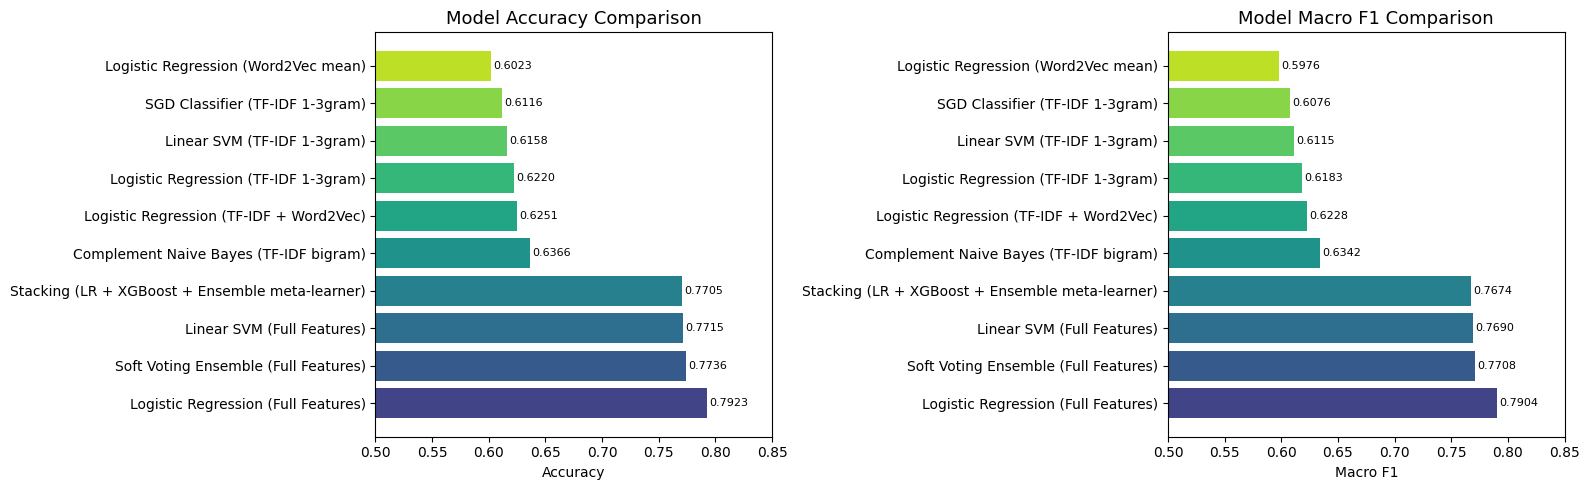

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))

bars1 = axes[0].barh(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0].set_xlim(0.5, 0.85)
axes[0].set_title('Model Accuracy Comparison', fontsize=13)
axes[0].set_xlabel('Accuracy')
for bar, val in zip(bars1, results_df['Accuracy']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

bars2 = axes[1].barh(results_df['Model'], results_df['Macro F1'], color=colors)
axes[1].set_xlim(0.5, 0.85)
axes[1].set_title('Model Macro F1 Comparison', fontsize=13)
axes[1].set_xlabel('Macro F1')
for bar, val in zip(bars2, results_df['Macro F1']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

Best model: Logistic Regression (Full Features)


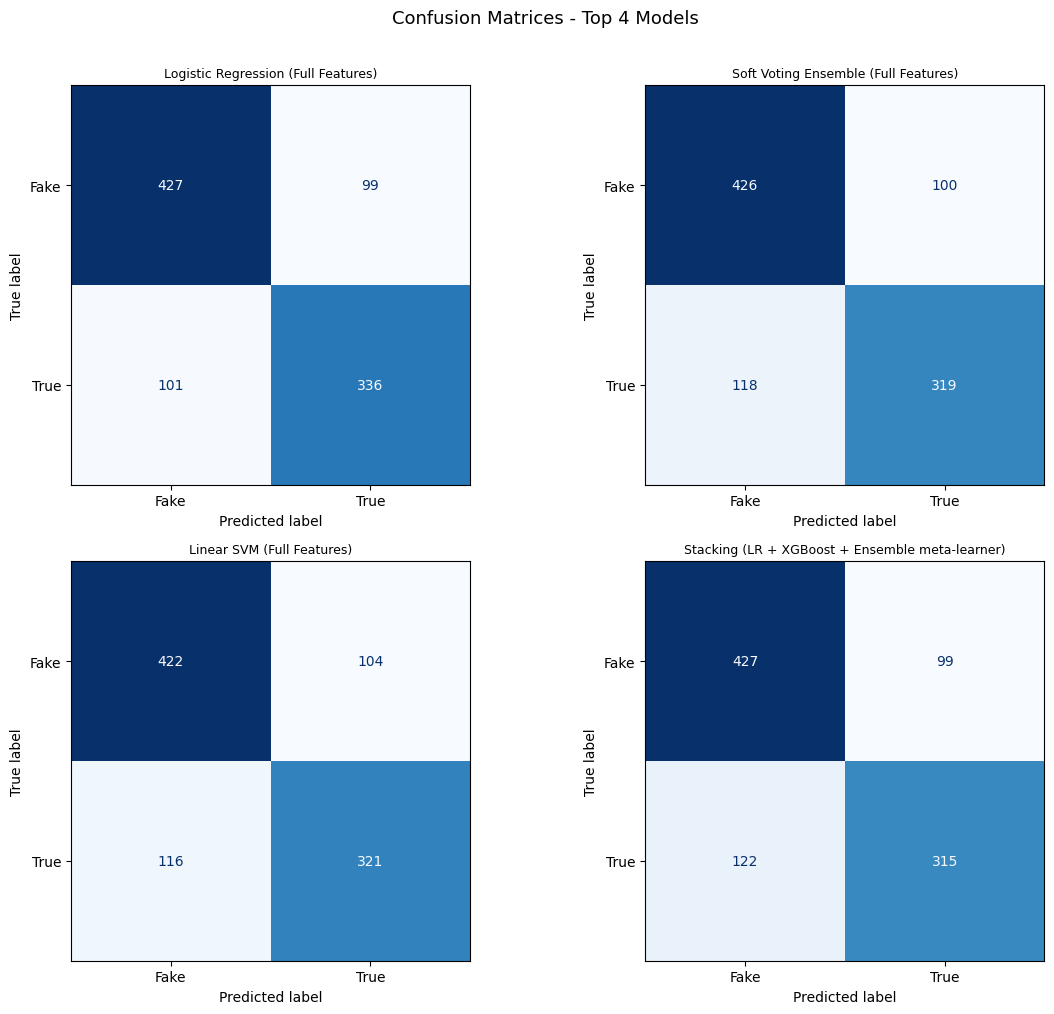

In [48]:
best_model_name = results_df.iloc[0]['Model']
print('Best model:', best_model_name)

model_map = {
    'Complement Naive Bayes (TF-IDF bigram)': (cnb, X_tfidf2_test, pred_cnb),
    'Logistic Regression (TF-IDF 1-3gram)': (lr_tfidf, X_tfidf3_test, pred_lr_tfidf),
    'Linear SVM (TF-IDF 1-3gram)': (svm, X_tfidf3_test, pred_svm),
    'SGD Classifier (TF-IDF 1-3gram)': (sgd, X_tfidf3_test, pred_sgd),
    'Logistic Regression (Word2Vec mean)': (lr_w2v, X_w2v_test, pred_lr_w2v),
    'Logistic Regression (TF-IDF + Word2Vec)': (lr_combined, X_tfidf_w2v_test, pred_lr_combined),
    'Logistic Regression (Full Features)': (lr_full, X_full_test, pred_lr_full),
    'Linear SVM (Full Features)': (svm_full, X_full_test, pred_svm_full),
    'Soft Voting Ensemble (Full Features)': (ensemble, X_full_test, pred_ens),
    'Stacking (LR + XGBoost + Ensemble meta-learner)': (meta_clf, stack_meta_test, pred_stack),
}

top4 = results_df.head(4)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.flatten(), top4):
    _, _, preds = model_map[name]
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'True'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices - Top 4 Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

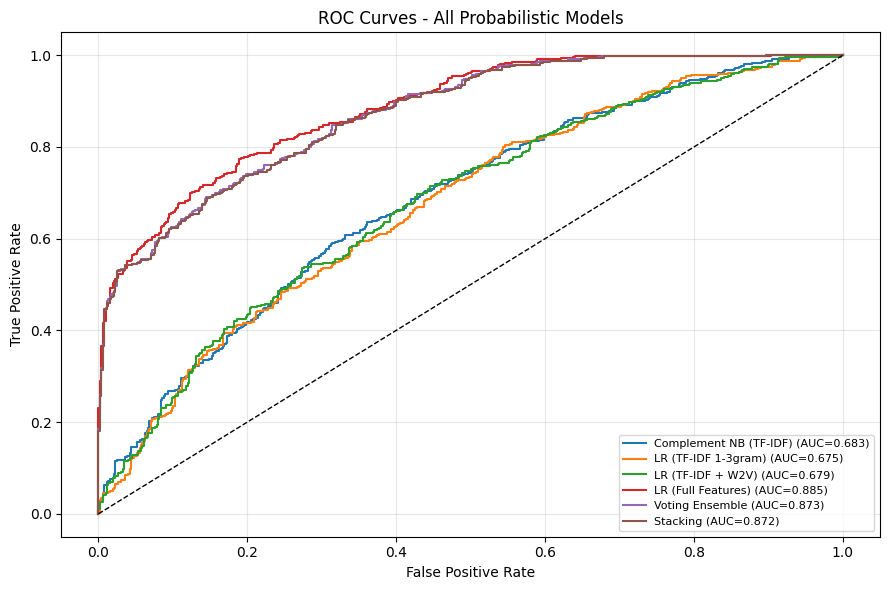

In [49]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))
prob_map = {
    'Complement NB (TF-IDF)': prob_cnb,
    'LR (TF-IDF 1-3gram)': prob_lr_tfidf,
    'LR (TF-IDF + W2V)': prob_lr_combined,
    'LR (Full Features)': prob_lr_full,
    'Voting Ensemble': prob_ens,
    'Stacking': prob_stack,
}

for name, probs in prob_map.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Probabilistic Models')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

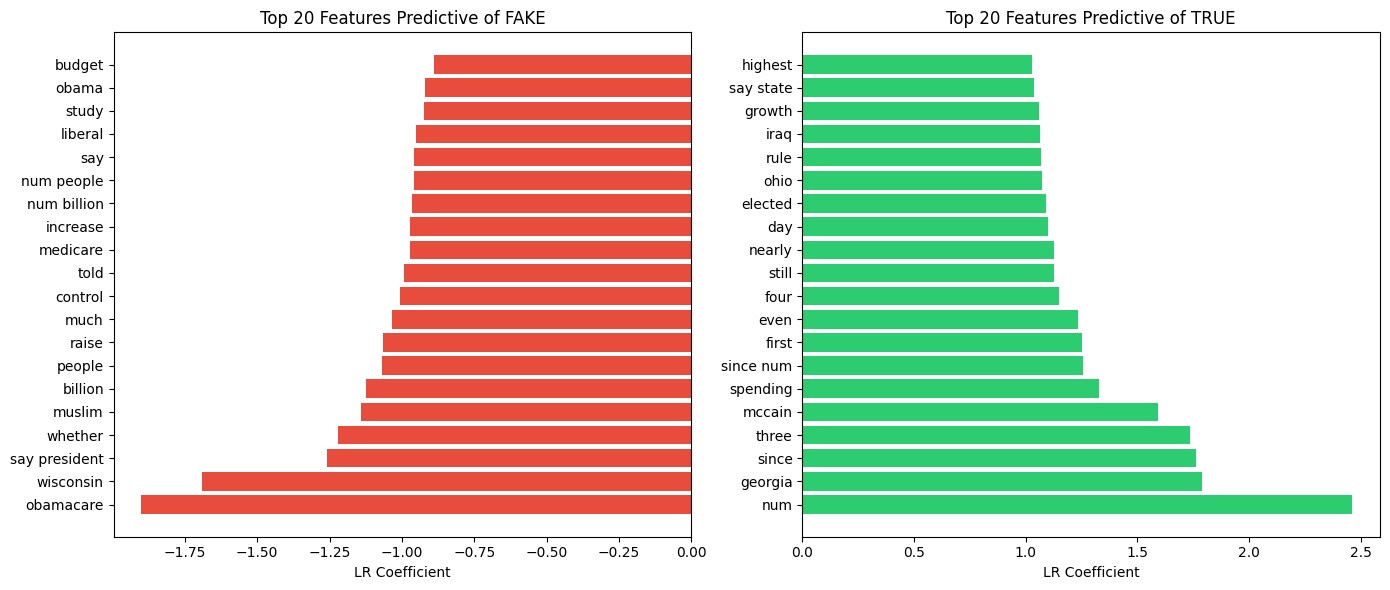

In [50]:
tfidf_words = np.array(tfidf_trigram.get_feature_names_out())
coefs = lr_tfidf.coef_[0]

top_fake_idx = np.argsort(coefs)[:20]
top_true_idx = np.argsort(coefs)[-20:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(tfidf_words[top_fake_idx], coefs[top_fake_idx], color='#e74c3c')
axes[0].set_title('Top 20 Features Predictive of FAKE', fontsize=12)
axes[0].set_xlabel('LR Coefficient')

axes[1].barh(tfidf_words[top_true_idx], coefs[top_true_idx], color='#2ecc71')
axes[1].set_title('Top 20 Features Predictive of TRUE', fontsize=12)
axes[1].set_xlabel('LR Coefficient')

plt.tight_layout()
plt.show()

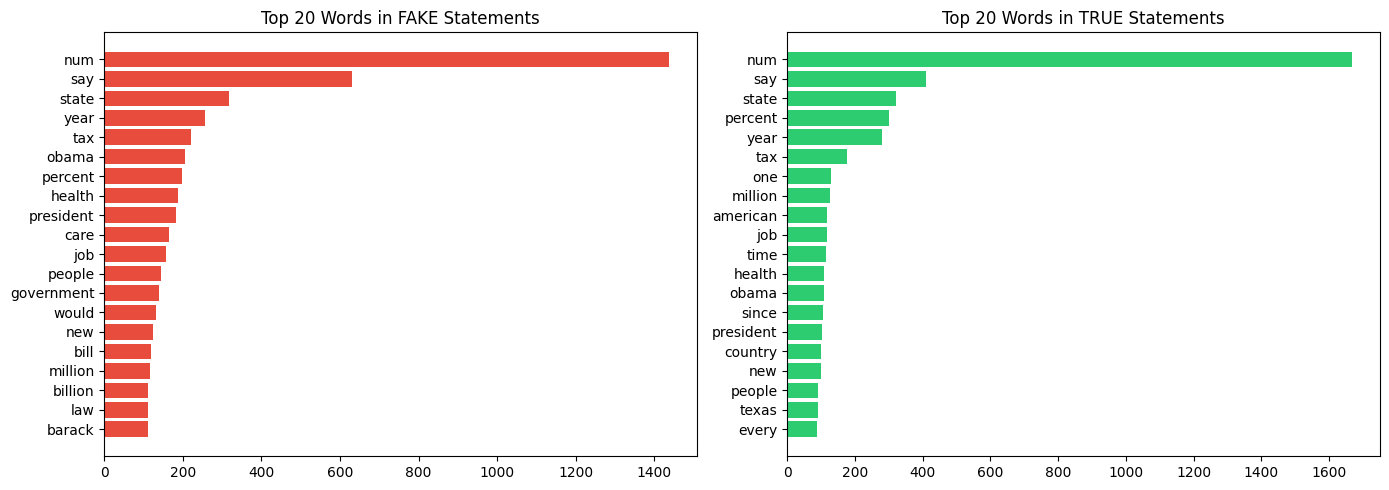

In [51]:
fake_words = ' '.join(df[df['label'] == 0]['statement_clean'])
true_words = ' '.join(df[df['label'] == 1]['statement_clean'])

fake_freq = FreqDist(fake_words.split())
true_freq = FreqDist(true_words.split())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_fake_words = fake_freq.most_common(20)
axes[0].barh([w for w, _ in top_fake_words[::-1]], [c for _, c in top_fake_words[::-1]], color='#e74c3c')
axes[0].set_title('Top 20 Words in FAKE Statements')

top_true_words = true_freq.most_common(20)
axes[1].barh([w for w, _ in top_true_words[::-1]], [c for _, c in top_true_words[::-1]], color='#2ecc71')
axes[1].set_title('Top 20 Words in TRUE Statements')

plt.tight_layout()
plt.show()

In [52]:
print('Top 5 Word2Vec similar words:')
probe_words = ['government', 'tax', 'health', 'crime', 'elect']
for word in probe_words:
    try:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f'\n{word}: {similar}')
    except KeyError:
        pass

Top 5 Word2Vec similar words:

government: [('teleschool', 0.6093920469284058), ('onto', 0.6059153079986572), ('ehsaas', 0.6035361289978027), ('channel', 0.6010345220565796), ('hari', 0.5977867245674133)]

tax: [('bracket', 0.6959611773490906), ('income_tax', 0.6953206658363342), ('middle_class', 0.6770172119140625), ('impose', 0.6724464893341064), ('hedge_fund', 0.6695721745491028)]

health: [('coverage', 0.801276445388794), ('bureaucrat', 0.800578773021698), ('initiative', 0.7966179251670837), ('human', 0.7941965460777283), ('maternity', 0.7851872444152832)]

crime: [('murder', 0.8472572565078735), ('decline', 0.8402324318885803), ('robbery', 0.8264866471290588), ('firearm', 0.82178795337677), ('convicted', 0.8118202686309814)]

elect: [('stood', 0.9598778486251831), ('ahead', 0.9376392364501953), ('rolled', 0.9294430017471313), ('ran', 0.9277324676513672), ('rick', 0.9239458441734314)]


In [53]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all_tfidf = tfidf_trigram.transform(df['statement_clean'])
X_all_w2v   = csr_matrix(X_w2v_all)
X_cv = hstack([X_all_tfidf, X_all_w2v, csr_matrix(dense_feats_all)])

cv_clf = LogisticRegression(C=0.5, solver='saga', max_iter=1000,
                             class_weight='balanced', random_state=42)
cv_scores = cross_val_score(cv_clf, X_cv, y, cv=skf, scoring='f1_macro', n_jobs=-1)

print(f'5-Fold CV Macro F1 Scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV Macro F1 Scores: [0.6017939  0.6109815  0.58975978 0.59745427 0.59419289]
Mean: 0.5988 +/- 0.0072


In [54]:
print('\n===== FINAL RESULTS SUMMARY =====')
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
print(f'\nBest Model : {best["Model"]}')
print(f'Accuracy   : {best["Accuracy"]:.4f}')
print(f'Macro F1   : {best["Macro F1"]:.4f}')
if pd.notna(best['AUC-ROC']):
    print(f'AUC-ROC    : {best["AUC-ROC"]:.4f}')


===== FINAL RESULTS SUMMARY =====
                                          Model  Accuracy  Macro F1  AUC-ROC
            Logistic Regression (Full Features)  0.792316  0.790444 0.884666
           Soft Voting Ensemble (Full Features)  0.773624  0.770794 0.873468
                     Linear SVM (Full Features)  0.771547  0.769006      NaN
Stacking (LR + XGBoost + Ensemble meta-learner)  0.770509  0.767362 0.871884
         Complement Naive Bayes (TF-IDF bigram)  0.636552  0.634214 0.683471
        Logistic Regression (TF-IDF + Word2Vec)  0.625130  0.622780 0.678629
           Logistic Regression (TF-IDF 1-3gram)  0.622015  0.618300 0.674896
                    Linear SVM (TF-IDF 1-3gram)  0.615784  0.611511      NaN
                SGD Classifier (TF-IDF 1-3gram)  0.611630  0.607650 0.653216
            Logistic Regression (Word2Vec mean)  0.602285  0.597591 0.637822


Best Model : Logistic Regression (Full Features)
Accuracy   : 0.7923
Macro F1   : 0.7904
AUC-ROC    : 0.8847


In [55]:
import joblib
import pickle

joblib.dump(tfidf_trigram, 'tfidf_trigram.pkl')
joblib.dump(lr_full, 'lr_full.pkl')
w2v_model.save('w2v_model.model')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']